# From Climate Grids to Urban Insights — Part 2
## Efficient and Scalable Processing for Large Spatiotemporal Data

**Summer School on Data Analytics and Simulation for City Digital Twins**  


---

### Where We Left Off

In Part 1, we built a complete pipeline: raw NetCDF grids → xarray → spatial aggregation → parquet → EDA. The code **works**, but as your datasets grow (more cities, finer resolution, longer time series, multiple variables), you'll hit two walls:

1. **Speed** — loops and row-by-row operations that were fine for one city become painfully slow at scale
2. **Memory** — datasets that don't fit in RAM at all

This session tackles both:

| Block | Topic | Time |
|-------|-------|------|
| 6 | Vectorisation: Why Loops Are Slow and What to Do Instead | ~30 min |
| 7 | Dask: When Your Data Doesn't Fit in Memory | ~25 min |
| Wrap-up | Putting It All Together | ~5 min |

### Prerequisites

We'll use the **parquet files** produced in Part 1. If you're joining fresh, you can load the combined file directly.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import time
import gc
from pathlib import Path

# Define paths — adjust these to match your folder structure
DATA_DIR = Path("london_data/raw_nc")       # folder with ldn_tp_YYYY.nc files
OUTPUT_DIR = Path("london_data/parquet")     # where we'll save processed parquet files
GEO_DIR = Path("london_data/geo")           # borough boundaries

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

YEARS = range(2000, 2019)  # 2000 to 2018 inclusive

In [2]:
# Load the combined dataset from Part 1
df = pd.read_parquet("london_data/parquet/ldn_nrr95p_all_years.parquet")
df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Shape: 305,360 rows × 5 columns
Memory: 25.0 MB


,name,time,nrr95p,year,month
0,Lewisham,2000-01-01,0.038095,2000,1
1,Lewisham,2000-01-02,0.001528,2000,1
2,Lewisham,2000-01-03,0.948212,2000,1
3,Lewisham,2000-01-04,0.039464,2000,1
4,Lewisham,2000-01-05,0.001609,2000,1



## Block 6 — Vectorisation: Why Loops Are Slow and What to Do Instead 

### 6.1 The Core Idea

Python is an **interpreted** language — each line is translated to machine code at runtime. When you write a `for` loop over a million rows, Python has to:

1. Check the type of each element
2. Look up the operation
3. Execute it
4. Store the result

...for **every single iteration**. This overhead is negligible for 100 iterations but devastating for 1,000,000.

**Vectorised operations** push the loop into C/Fortran code inside NumPy or pandas, where:
- Type checking happens once (the whole array has one dtype)
- The operation is applied to all elements in a single compiled call
- Modern CPUs can process multiple elements simultaneously (SIMD instructions)

The rule of thumb: **if you're writing a `for` loop over rows of a DataFrame, there's almost certainly a faster way.**

### 6.2 A Concrete Task: Classifying Extreme Events

Let's say we want to classify each borough-day into a risk category:

| nrr95p value | Category |
|---|---|
| 0 | No event |
| 0 < nrr95p ≤ 1 | Below threshold |
| 1 < nrr95p ≤ 2 | Moderate |
| 2 < nrr95p ≤ 3 | Severe |
| > 3 | Extreme |

We'll implement this **four different ways** and time each one.

In [3]:
# Helper: timing decorator
def time_it(func, *args, n_runs=3, **kwargs):
    """Run a function multiple times and return the average time."""
    times = []
    for _ in range(n_runs):
        t0 = time.time()
        result = func(*args, **kwargs)
        times.append(time.time() - t0)
    avg = np.mean(times)
    return result, avg

#### Method 1: Python `for` Loop (the naive way)

In [4]:
def classify_loop(df):
    """Classify using a Python for loop — row by row."""
    categories = []
    for val in df['nrr95p']:
        if val == 0:
            categories.append('No event')
        elif val <= 1:
            categories.append('Below threshold')
        elif val <= 2:
            categories.append('Moderate')
        elif val <= 3:
            categories.append('Severe')
        else:
            categories.append('Extreme')
    return categories

_, t_loop = time_it(classify_loop, df)
print(f"for loop: {t_loop:.3f}s")

for loop: 0.027s


#### Method 2: `.apply()` (looks clean, but still slow)

Many people reach for `.apply()` thinking it's "the pandas way". It's not — under the hood, it's still a Python loop with extra overhead.

In [5]:
def classify_single(val):
    if val == 0:
        return 'No event'
    elif val <= 1:
        return 'Below threshold'
    elif val <= 2:
        return 'Moderate'
    elif val <= 3:
        return 'Severe'
    else:
        return 'Extreme'

def classify_apply(df):
    """Classify using .apply() — still a loop in disguise."""
    return df['nrr95p'].apply(classify_single)

_, t_apply = time_it(classify_apply, df)
print(f".apply(): {t_apply:.3f}s")

.apply(): 0.041s


#### Method 3: `np.select()` (fully vectorised)

This is the standard vectorised approach for multi-condition classification. All conditions are evaluated as boolean arrays across the entire column simultaneously.

In [6]:
def classify_np_select(df):
    """Classify using np.select — fully vectorised."""
    conditions = [
        df['nrr95p'] == 0,
        df['nrr95p'] <= 1,
        df['nrr95p'] <= 2,
        df['nrr95p'] <= 3,
    ]
    choices = ['No event', 'Below threshold', 'Moderate', 'Severe']
    return np.select(conditions, choices, default='Extreme')

_, t_select = time_it(classify_np_select, df)
print(f"np.select(): {t_select:.3f}s")

np.select(): 0.010s


#### Method 4: `pd.cut()` (built for exactly this)

In [7]:
def classify_pd_cut(df):
    """Classify using pd.cut — purpose-built for binning."""
    return pd.cut(
        df['nrr95p'],
        bins=[-np.inf, 0, 1, 2, 3, np.inf],
        labels=['No event', 'Below threshold', 'Moderate', 'Severe', 'Extreme']
    )

_, t_cut = time_it(classify_pd_cut, df)
print(f"pd.cut(): {t_cut:.3f}s")

pd.cut(): 0.006s


#### The Comparison

In [8]:
# Summary
results = {
    'for loop': t_loop,
    '.apply()': t_apply,
    'np.select()': t_select,
    'pd.cut()': t_cut
}

fastest = min(results.values())

print(f"{'Method':<15} {'Time (s)':<12} {'Speedup vs loop':<18}")
print(f"{'-'*45}")
for method, t in results.items():
    print(f"{method:<15} {t:<12.4f} {t_loop/t:<18.1f}×")

print(f"\nRows processed: {len(df):,}")

Method          Time (s)     Speedup vs loop   
---------------------------------------------
for loop        0.0273       1.0               ×
.apply()        0.0414       0.7               ×
np.select()     0.0100       2.7               ×
pd.cut()        0.0057       4.8               ×

Rows processed: 305,360


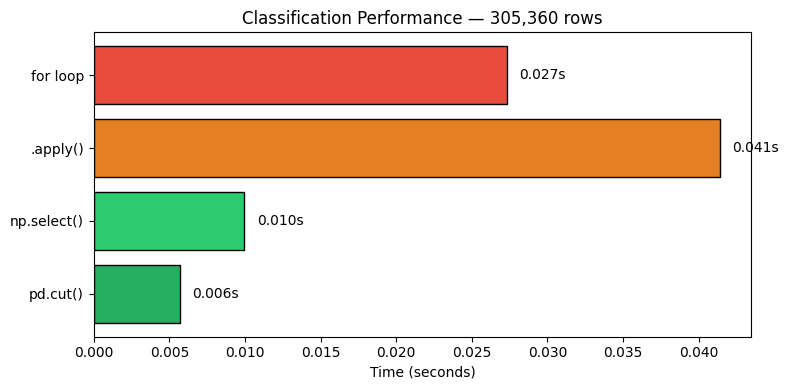

In [9]:
# Visualise the comparison
fig, ax = plt.subplots(figsize=(8, 4))
methods = list(results.keys())
times = list(results.values())
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#27ae60']

bars = ax.barh(methods, times, color=colors, edgecolor='black')
ax.set_xlabel('Time (seconds)')
ax.set_title(f'Classification Performance — {len(df):,} rows')

# Add time labels on bars
for bar, t in zip(bars, times):
    ax.text(bar.get_width() + max(times)*0.02, bar.get_y() + bar.get_height()/2,
            f'{t:.3f}s', va='center', fontsize=10)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 6.3 Another Example: Computing Rolling Anomalies

A common analytical task: for each borough-day, compute how the nrr95p value compares to that borough's historical monthly average. This is a **grouped rolling computation** — exactly the kind of thing that tempts people into nested loops.

#### The Naive Way: Nested Loops

In [10]:
def anomaly_loop(df):
    """Compute monthly anomaly per borough using nested loops."""
    result = np.empty(len(df))
    for borough in df['name'].unique():
        for month in range(1, 13):
            mask = (df['name'] == borough) & (df['month'] == month)
            monthly_mean = df.loc[mask, 'nrr95p'].mean()
            result[mask.values] = df.loc[mask, 'nrr95p'].values - monthly_mean
    return result

_, t_anomaly_loop = time_it(anomaly_loop, df, n_runs=1)
print(f"Nested loop: {t_anomaly_loop:.3f}s")

Nested loop: 0.936s


#### The Vectorised Way: `groupby().transform()`

In [11]:
def anomaly_vectorised(df):
    """Compute monthly anomaly per borough using groupby + transform."""
    monthly_mean = df.groupby(['name', 'month'])['nrr95p'].transform('mean')
    return df['nrr95p'] - monthly_mean

_, t_anomaly_vec = time_it(anomaly_vectorised, df)
print(f"groupby + transform: {t_anomaly_vec:.3f}s")
print(f"\nSpeedup: {t_anomaly_loop / t_anomaly_vec:.1f}×")

groupby + transform: 0.013s

Speedup: 73.1×


**Why is `transform` so powerful?**

`.transform()` returns a result with the **same index** as the input — it broadcasts the group-level computation back to every row. This means you can write `df['nrr95p'] - df.groupby(...).transform('mean')` in one line, and pandas handles all the matching internally. No manual looping, no boolean masks, no indexing errors.

Some common `transform` patterns:

```python
# Z-score within each group
df['zscore'] = df.groupby('name')['nrr95p'].transform(lambda x: (x - x.mean()) / x.std())

# Percentage of group total
df['pct'] = df['nrr95p'] / df.groupby('year')['nrr95p'].transform('sum')

# Flag: above group median
df['above_median'] = df['nrr95p'] > df.groupby('name')['nrr95p'].transform('median')
```

### 6.4 Aggregation: `groupby().agg()` vs Loops

Another common pattern: computing multiple summary statistics per group. Let's compute, for each borough and year, the mean, max, count of extreme days, and the 95th percentile.

In [12]:
def summary_loop(df):
    """Compute summary stats per borough-year using loops."""
    rows = []
    for borough in df['name'].unique():
        for year in df['year'].unique():
            mask = (df['name'] == borough) & (df['year'] == year)
            subset = df.loc[mask, 'nrr95p']
            rows.append({
                'name': borough,
                'year': year,
                'mean': subset.mean(),
                'max': subset.max(),
                'extreme_days': (subset > 1).sum(),
                'p95': subset.quantile(0.95)
            })
    return pd.DataFrame(rows)

_, t_summary_loop = time_it(summary_loop, df, n_runs=1)
print(f"Nested loop: {t_summary_loop:.3f}s")

Nested loop: 1.534s


In [13]:
def summary_vectorised(df):
    """Compute summary stats per borough-year using groupby.agg()."""
    return df.groupby(['name', 'year'])['nrr95p'].agg(
        mean='mean',
        max='max',
        extreme_days=lambda x: (x > 1).sum(),
        p95=lambda x: x.quantile(0.95)
    ).reset_index()

_, t_summary_vec = time_it(summary_vectorised, df)
print(f"groupby.agg(): {t_summary_vec:.3f}s")
print(f"\nSpeedup: {t_summary_loop / t_summary_vec:.1f}×")

groupby.agg(): 0.052s

Speedup: 29.3×


### 6.5 Quick Wins: dtype Optimisation

Vectorisation isn't just about computation speed — memory matters too. Choosing the right dtypes can significantly reduce memory usage, which means faster operations (less data to move through the CPU cache) and the ability to work with larger datasets.

In [14]:
# Current memory usage
print("Before optimisation:")
print(df.dtypes)
mem_before = df.memory_usage(deep=True).sum() / 1e6
print(f"\nTotal memory: {mem_before:.1f} MB")
print()

# Per-column breakdown
for col in df.columns:
    col_mem = df[col].memory_usage(deep=True) / 1e6
    print(f"  {col:<10} {str(df[col].dtype):<20} {col_mem:.2f} MB")

Before optimisation:
name              object
time      datetime64[ns]
nrr95p           float64
year               int32
month              int32
dtype: object

Total memory: 25.0 MB

  name       object               17.68 MB
  time       datetime64[ns]       2.44 MB
  nrr95p     float64              2.44 MB
  year       int32                1.22 MB
  month      int32                1.22 MB


In [15]:
# Optimise dtypes
df_opt = df.copy()

# 1. Borough name: convert to 'category' dtype
#    Instead of storing the full string "City of London" for every row,
#    pandas stores an integer code + a small lookup table
df_opt['name'] = df_opt['name'].astype('category')

# 2. nrr95p: float64 → float32 (we don't need 15 decimal places)
df_opt['nrr95p'] = df_opt['nrr95p'].astype('float32')

# 3. year and month: int64 → int16 (values fit in 16 bits easily)
df_opt['year'] = df_opt['year'].astype('int16')
df_opt['month'] = df_opt['month'].astype('int16')

mem_after = df_opt.memory_usage(deep=True).sum() / 1e6

print("After optimisation:")
for col in df_opt.columns:
    col_mem = df_opt[col].memory_usage(deep=True) / 1e6
    print(f"  {col:<10} {str(df_opt[col].dtype):<20} {col_mem:.2f} MB")

print(f"\nMemory: {mem_before:.1f} MB → {mem_after:.1f} MB ({(1 - mem_after/mem_before)*100:.0f}% reduction)")

After optimisation:
  name       category             0.31 MB
  time       datetime64[ns]       2.44 MB
  nrr95p     float32              1.22 MB
  year       int16                0.61 MB
  month      int16                0.61 MB

Memory: 25.0 MB → 5.2 MB (79% reduction)


In [16]:
# Does the dtype change affect computation speed?
_, t_original = time_it(lambda: df.groupby(['name', 'year'])['nrr95p'].mean(), n_runs=5)
_, t_optimised = time_it(lambda: df_opt.groupby(['name', 'year'])['nrr95p'].mean(), n_runs=5)

print(f"groupby mean — original dtypes: {t_original:.4f}s")
print(f"groupby mean — optimised dtypes: {t_optimised:.4f}s")
print(f"Speedup: {t_original/t_optimised:.2f}×")

groupby mean — original dtypes: 0.0141s
groupby mean — optimised dtypes: 0.0069s
Speedup: 2.04×


/var/folders/nt/03y4p9md50gblp_0svv74zb80000gn/T/ipykernel_66584/2918057425.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _, t_optimised = time_it(lambda: df_opt.groupby(['name', 'year'])['nrr95p'].mean(), n_runs=5)


### 6.6 Selective Column Reading from Parquet

One of parquet's best features: you can read **only the columns you need**. With CSV, you always read the entire file and then discard columns.

In [17]:
# Read all columns
_, t_all = time_it(
    lambda: pd.read_parquet(OUTPUT_DIR / 'ldn_nrr95p_all_years.parquet'),
    n_runs=5
)

# Read only the columns we need
_, t_subset = time_it(
    lambda: pd.read_parquet(OUTPUT_DIR / 'ldn_nrr95p_all_years.parquet', columns=['name', 'nrr95p']),
    n_runs=5
)

print(f"Read all columns:    {t_all:.4f}s")
print(f"Read 2 columns only: {t_subset:.4f}s")
print(f"\nWith CSV, both reads take the same time — parquet only reads what you ask for.")

Read all columns:    0.0070s
Read 2 columns only: 0.0055s

With CSV, both reads take the same time — parquet only reads what you ask for.



- **Never iterate row-by-row** over a DataFrame if you can avoid it. Use `np.select`, `pd.cut`, `groupby().transform()`, or `groupby().agg()` instead.
- **`.apply()` is a trap** — it looks like pandas but is just a loop with extra overhead.
- **dtype optimisation** reduces memory and can speed up grouped operations — `category` for repeated strings, `float32` when precision allows, smaller integer types for bounded values.
- **Selective column reading** from parquet saves time when you don't need every column.

In [18]:
# Clean up before Dask section
del df_opt
gc.collect()

33


## Block 7 — Dask: When Your Data Doesn't Fit in Memory 

### 7.1 The Problem

Our London dataset is small enough to fit in memory. But imagine scaling up:

- 20 cities instead of 1 → 20× larger
- 1 km resolution instead of 2 km → 4× more grid cells
- Multiple variables → 2–5× more columns
- 50+ years of data → 3× longer time series

Suddenly your dataset is **hundreds of GB** — it won't fit in RAM. You can't just `pd.read_parquet()` it.

**Dask** solves this by:

1. **Lazy evaluation** — it builds a computation graph but doesn't execute until you call `.compute()`
2. **Chunked processing** — it splits your data into pieces that fit in memory and processes them one at a time
3. **Familiar API** — `dask.dataframe` mirrors pandas, and dask-backed xarray mirrors xarray

```
pandas:  Load everything → process → result
dask:    Define operations (lazy) → .compute() → load chunks → process chunks → combine → result
```

In [19]:
import dask.dataframe as dd

### 7.2 Loading Data with Dask

Remember in Part 1, we loaded each parquet file in a loop, appended to a list, and concatenated? Dask handles this natively.

In [20]:
# Pandas way (from Part 1): load all, concatenate
t0 = time.time()
dfs = [pd.read_parquet(f) for f in sorted(OUTPUT_DIR.glob('ldn_nrr95p_*.parquet'))]
df_pandas = pd.concat(dfs, ignore_index=True)
t_pandas = time.time() - t0
print(f"Pandas: loaded {len(df_pandas):,} rows in {t_pandas:.3f}s")
print(f"Memory: {df_pandas.memory_usage(deep=True).sum() / 1e6:.1f} MB")

del dfs
gc.collect()

Pandas: loaded 381,700 rows in 0.023s
Memory: 28.2 MB


20

In [21]:
# Dask way: read all parquet files as a single lazy dataframe
t0 = time.time()
ddf = dd.read_parquet(sorted(OUTPUT_DIR.glob('ldn_nrr95p_*.parquet')))
t_dask = time.time() - t0

print(f"Dask: 'loaded' in {t_dask:.4f}s")
print(f"\nBut it hasn't actually read any data yet!")
print(f"Type: {type(ddf)}")
print(f"Partitions: {ddf.npartitions}")
ddf

Dask: 'loaded' in 0.0115s

But it hasn't actually read any data yet!
Type: <class 'dask.dataframe.dask_expr._collection.DataFrame'>
Partitions: 20


,name,time,nrr95p
npartitions=20,,,
,string,datetime64[ns],float64
,...,...,...
...,...,...,...
,...,...,...
,...,...,...


**Notice:** Dask "loaded" the data almost instantly — but it hasn't read a single byte. It just recorded *where the files are* and *what operations we want*. The actual reading happens only when we call `.compute()`.

This is **lazy evaluation**: build the plan first, execute later.

### 7.3 Working with Dask DataFrames

The API is nearly identical to pandas — most operations just work.

In [22]:
# These operations are lazy — no computation yet
ddf['time'] = dd.to_datetime(ddf['time'])
ddf['year'] = ddf['time'].dt.year
ddf['month'] = ddf['time'].dt.month

# This is still lazy
annual_mean = ddf.groupby(['name', 'year'])['nrr95p'].mean()

print("Still lazy — no computation has happened:")
print(type(annual_mean))
annual_mean

Still lazy — no computation has happened:
<class 'dask.dataframe.dask_expr._collection.Series'>


Dask Series Structure:
npartitions=1
    float64
        ...
Dask Name: getitem, 13 expressions
Expr=((Assign(frame=Assign(frame=Assign(frame=ReadParquetFSSpec(2800d47))))[['name', 'nrr95p', 'year']]).mean(observed=False, chunk_kwargs={'numeric_only': False}, aggregate_kwargs={'numeric_only': False}, _slice='nrr95p'))['nrr95p']

In [23]:
# NOW we compute — this triggers the actual data reading and processing
t0 = time.time()
result = annual_mean.compute()
t_compute = time.time() - t0

print(f"Computed in {t_compute:.3f}s")
print(f"Result type: {type(result)}")
print(f"Result shape: {result.shape}")
result.head(10)

Computed in 0.339s
Result type: <class 'pandas.core.series.Series'>
Result shape: (209,)


name            year
City of London  2010    0.098292
Hackney         2010    0.099053
Haringey        2010    0.102917
Lambeth         2010    0.097571
Lewisham        2010    0.091233
Tower Hamlets   2010    0.095908
Camden          2011    0.095835
Islington       2011    0.095195
Newham          2011    0.088276
Southwark       2011    0.094389
Name: nrr95p, dtype: float64

### 7.4 Why Dask Matters: Replacing the Loop-Concat Pattern

In Part 1 (Block 4), we processed each year in a loop:

```python
for year in YEARS:
    ds = xr.open_dataset(f"ldn_tp_{year}.nc")
    # ... process ...
    df.to_parquet(f"ldn_nrr95p_{year}.parquet")
    del ds; gc.collect()
```

Then loaded them all back:

```python
dfs = [pd.read_parquet(f) for f in parquet_files]
df_all = pd.concat(dfs)
```

With Dask, the second step becomes trivial — and you can do further analytics **without loading everything into memory**:

In [24]:
# Dask can compute complex aggregations across all files without loading them all at once
t0 = time.time()

# This reads each partition, computes the aggregation, and combines — all chunked
extreme_summary = (
    ddf[ddf['nrr95p'] > 1]
    .groupby('name')
    .agg({'nrr95p': ['count', 'mean', 'max']})
    .compute()
)

t_agg = time.time() - t0
extreme_summary.columns = ['total_extreme_days', 'mean_intensity', 'max_event']

print(f"Computed in {t_agg:.3f}s")
extreme_summary.sort_values('max_event', ascending=False)

Computed in 0.058s


,total_extreme_days,mean_intensity,max_event
name,,,
City of London,570,1.413924,4.926423
Lambeth,520,1.385359,4.873206
Hackney,540,1.398374,4.437912
Westminster,540,1.356952,4.369265
Tower Hamlets,550,1.437250,4.193092
Islington,545,1.383471,3.988710
Newham,550,1.392136,3.733063
Southwark,525,1.398258,3.722214
Haringey,550,1.368865,3.370916


### 7.5 Dask + xarray: Lazy-Loading NetCDF Files

Dask also integrates with xarray. Instead of our loop that opens each file one at a time, xarray can open **all files at once** with lazy loading — it only reads data into memory when you actually compute on it.

In [25]:
# Open all NetCDF files at once with lazy loading via dask
nc_files = sorted(DATA_DIR.glob('ldn_tp_*.nc'))

t0 = time.time()
ds_all = xr.open_mfdataset(
    nc_files,
    combine='by_coords',  # align files along the time dimension
    chunks={'time': 365}  # chunk size — one year per chunk
)
t_open = time.time() - t0

print(f"Opened {len(nc_files)} files in {t_open:.3f}s (lazy — no data loaded yet)")
print(f"Time range: {ds_all.time.values[0]} to {ds_all.time.values[-1]}")
print(f"Total time steps: {len(ds_all.time)}")
ds_all

Opened 19 files in 0.209s (lazy — no data loaded yet)
Time range: 2000-01-01T00:00:00.000000000 to 2018-12-31T00:00:00.000000000
Total time steps: 6940


<xarray.Dataset> Size: 118MB
Dimensions:    (time: 6940, rlat: 52, rlon: 41)
Coordinates:
  * rlon       (rlon) float64 328B 2.018 2.038 2.058 2.078 ... 2.778 2.798 2.818
  * rlat       (rlat) float64 416B -2.944 -2.924 -2.904 ... -1.964 -1.944 -1.924
    longitude  (rlat, rlon) float64 17kB dask.array<chunksize=(52, 41), meta=np.ndarray>
    latitude   (rlat, rlon) float64 17kB dask.array<chunksize=(52, 41), meta=np.ndarray>
  * time       (time) datetime64[ns] 56kB 2000-01-01 2000-01-02 ... 2018-12-31
Data variables:
    nrr95p     (time, rlat, rlon) float64 118MB dask.array<chunksize=(365, 52, 41), meta=np.ndarray>
Attributes:
    institution:  Fondazione Centro Euro-Mediterraneo sui Cambiamenti Climati...
    experiment:   ERA5-2km i.e., cclm-sp_2.4_terra_urb_2.3.1 simulation (0.02...
    references:   http//www.clm-community.eu, http://www.cmcc.it
    Conventions:  CF-1.6
    contacts:     copernicus-support@ecmwf.int
    contract:     C3S_430 Sectoral Information System to support Disaster Ris...
    title:        Extreme precipitation indicators for Europe and European ci...
    author:       Fondazione Centro Euro-Mediterraneo sui Cambiamenti Climati...
    version:      version 1.0

In [26]:
# Notice the chunk structure — each chunk is one year
print("Chunk structure:")
print(ds_all['nrr95p'].chunks)

Chunk structure:
((365, 1, 365, 365, 365, 365, 1, 365, 365, 365, 365, 1, 365, 365, 365, 365, 1, 365, 365, 365, 365, 1, 365, 365), (52,), (41,))


Computed 19-year temporal mean in 0.076s


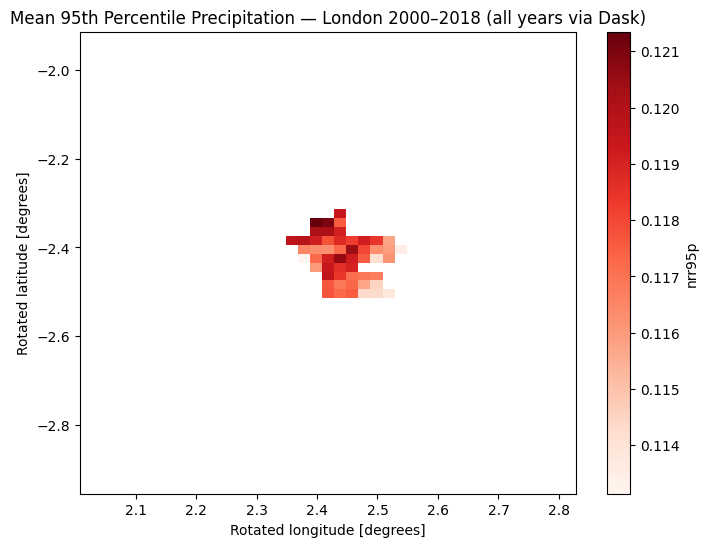

In [27]:
# Compute the temporal mean across ALL years — lazily
all_years_mean = ds_all['nrr95p'].mean(dim='time')

# Still lazy — let's trigger computation
t0 = time.time()
result_array = all_years_mean.compute()
t_compute = time.time() - t0

print(f"Computed 19-year temporal mean in {t_compute:.3f}s")

# Plot
result_array.plot(figsize=(8, 6), cmap='Reds')
plt.title('Mean 95th Percentile Precipitation — London 2000–2018 (all years via Dask)')
plt.show()

**Compare this to the Part 1 approach:** In Part 1, we had to loop over each file, convert to pandas, aggregate with xagg, save to parquet, and then load them all back. With `open_mfdataset` + dask, xarray handles the chunking and orchestration for you — and only loads into memory the chunks it needs at any given time.

For operations that stay in the xarray/grid world (temporal means, anomalies, trend computation), this is much cleaner. You'd still need xagg for the spatial aggregation to polygons, but all the pre-aggregation analytics can be done lazily.

### 7.6 When to Use Dask vs Pandas

| Situation | Use |
|-----------|-----|
| Data fits comfortably in memory | **pandas** — simpler, faster for small data |
| Data is large but each *file* fits in memory | **pandas in a loop** (our Part 1 pattern) or **Dask** |
| Data doesn't fit in memory at all | **Dask** — it handles chunking for you |
| Complex operations needing full random access | **pandas** — load what you can, sample if needed |
| Simple aggregations across many files | **Dask** — shines at grouped operations on partitioned data |
| Grid-level operations on NetCDF archives | **xarray + Dask** via `open_mfdataset` |

Dask has overhead — for small datasets, pandas is faster. Dask's advantage appears when your data is larger than RAM or when you want cleaner code for multi-file processing.

In [28]:
# Direct comparison: same aggregation in pandas vs dask

# Pandas
t0 = time.time()
res_pd = df.groupby('name')['nrr95p'].agg(['mean', 'max']).reset_index()
t_pd = time.time() - t0

# Dask
t0 = time.time()
res_dask = ddf.groupby('name')['nrr95p'].agg(['mean', 'max']).compute().reset_index()
t_dask = time.time() - t0

print(f"Pandas:  {t_pd:.4f}s")
print(f"Dask:    {t_dask:.4f}s")
print(f"\nFor this dataset size, pandas is faster — Dask's advantage is when data doesn't fit in RAM.")

# Verify results are the same
print(f"\nResults match: {np.allclose(res_pd['mean'].values, res_dask['mean'].values, rtol=1e-5)}")

Pandas:  0.0109s
Dask:    0.0642s

For this dataset size, pandas is faster — Dask's advantage is when data doesn't fit in RAM.

Results match: False



- **Dask uses lazy evaluation** — it builds a computation graph and only executes when you call `.compute()`
- **`dask.dataframe`** is nearly a drop-in replacement for pandas, useful when data exceeds RAM
- **`xr.open_mfdataset`** with Dask chunks lets you work with multi-file NetCDF archives without loading everything at once
- **Dask has overhead** — for datasets that fit in memory, pandas is usually faster. Use Dask when you need it, not by default.


## Wrap-Up

### The Full Picture

Across both sessions, we've covered a pipeline from raw data to analysis and the techniques for doing it efficiently at scale:

```
Part 1:  NetCDF → xarray → xagg aggregation → parquet → EDA
Part 2:  Vectorisation → dtype optimisation → Dask for scaling
```

### When to Reach for Each Tool

| Problem | Tool |
|---------|------|
| Row-by-row classification or binning | `np.select()`, `pd.cut()` |
| Group-level calculation broadcast to rows | `groupby().transform()` |
| Multiple summary stats per group | `groupby().agg()` |
| Repeated strings in a column | `category` dtype |
| Unnecessarily precise floats | `float32` |
| Reading only some columns | `pd.read_parquet(columns=[...])` |
| Data larger than RAM (tabular) | `dask.dataframe` |
| Data larger than RAM (gridded) | `xr.open_mfdataset(chunks=...)` |
| Multi-file loading without loops | `dd.read_parquet()` or `open_mfdataset()` |

### Further Resources

- **Dask documentation:** https://docs.dask.org
- **Dask best practices:** https://docs.dask.org/en/latest/best-practices.html
- **pandas performance tips:** https://pandas.pydata.org/docs/user_guide/enhancingperf.html
- **NumPy vectorisation guide:** https://numpy.org/doc/stable/user/basics.broadcasting.html
- **London Datastore** (for extending the analysis): https://data.london.gov.uk/